4. 裁掉组织矩形区域外的多余空白画布。用图像边缘中位色估计背景，检测组织紧包围盒；若盒外空白占整图面积超过阈值（默认 20%），则裁到该矩形（略留边）并覆盖原文件。`S079_4`、`S091_4`、`S105_4` 这类中心组织四周有大块扫描空白的应被裁剪；组织已铺满画面的文件会跳过。

[裁剪] S003_1.tif  8432x12000 -> 6960x11144  leftover=0.233
[跳过] S004_5.tif  leftover=0.014 < 0.2  shape=11240x7171
[跳过] S007_1.tif  leftover=0.177 < 0.2  shape=7497x12096
[跳过] S008_5.tif  leftover=0.011 < 0.2  shape=9541x9953
[跳过] S011_1.tif  leftover=0.038 < 0.2  shape=12691x8969
[跳过] S012_5.tif  leftover=0.056 < 0.2  shape=10744x9972
[跳过] S016_1.tif  leftover=0.069 < 0.2  shape=10342x12827
[跳过] S019_1.tif  leftover=0.088 < 0.2  shape=11576x13496
[跳过] S021_5.tif  leftover=0.000 < 0.2  shape=12835x13186
[跳过] S023_1.tif  leftover=0.080 < 0.2  shape=12744x14161
[跳过] S024_5.tif  leftover=0.062 < 0.2  shape=12556x12799
[跳过] S027_1.tif  leftover=0.056 < 0.2  shape=13221x13893
[跳过] S028_5.tif  leftover=0.020 < 0.2  shape=13131x13208
[跳过] S029_5.tif  leftover=0.131 < 0.2  shape=13967x12840
[跳过] S030_1.tif  leftover=0.019 < 0.2  shape=13270x13915
[跳过] S031_1.tif  leftover=0.039 < 0.2  shape=13392x13719
[跳过] S034_5.tif  leftover=0.049 < 0.2  shape=14520x14691
[跳过] S035_1.tif  leftover=0.016 < 0.

/mnt/zzf_nas/tmp/ipykernel_1358965/4132110441.py:208: UserWarning: Glyph 35009 (\N{CJK UNIFIED IDEOGRAPH-88C1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/zzf_nas/tmp/ipykernel_1358965/4132110441.py:208: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/zzf_nas/tmp/ipykernel_1358965/4132110441.py:208: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/zzf_nas/profound_data/code/envs/Spaceland-omics/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35009 (\N{CJK UNIFIED IDEOGRAPH-88C1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/zzf_nas/profound_data/code/envs/Spaceland-omics/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/

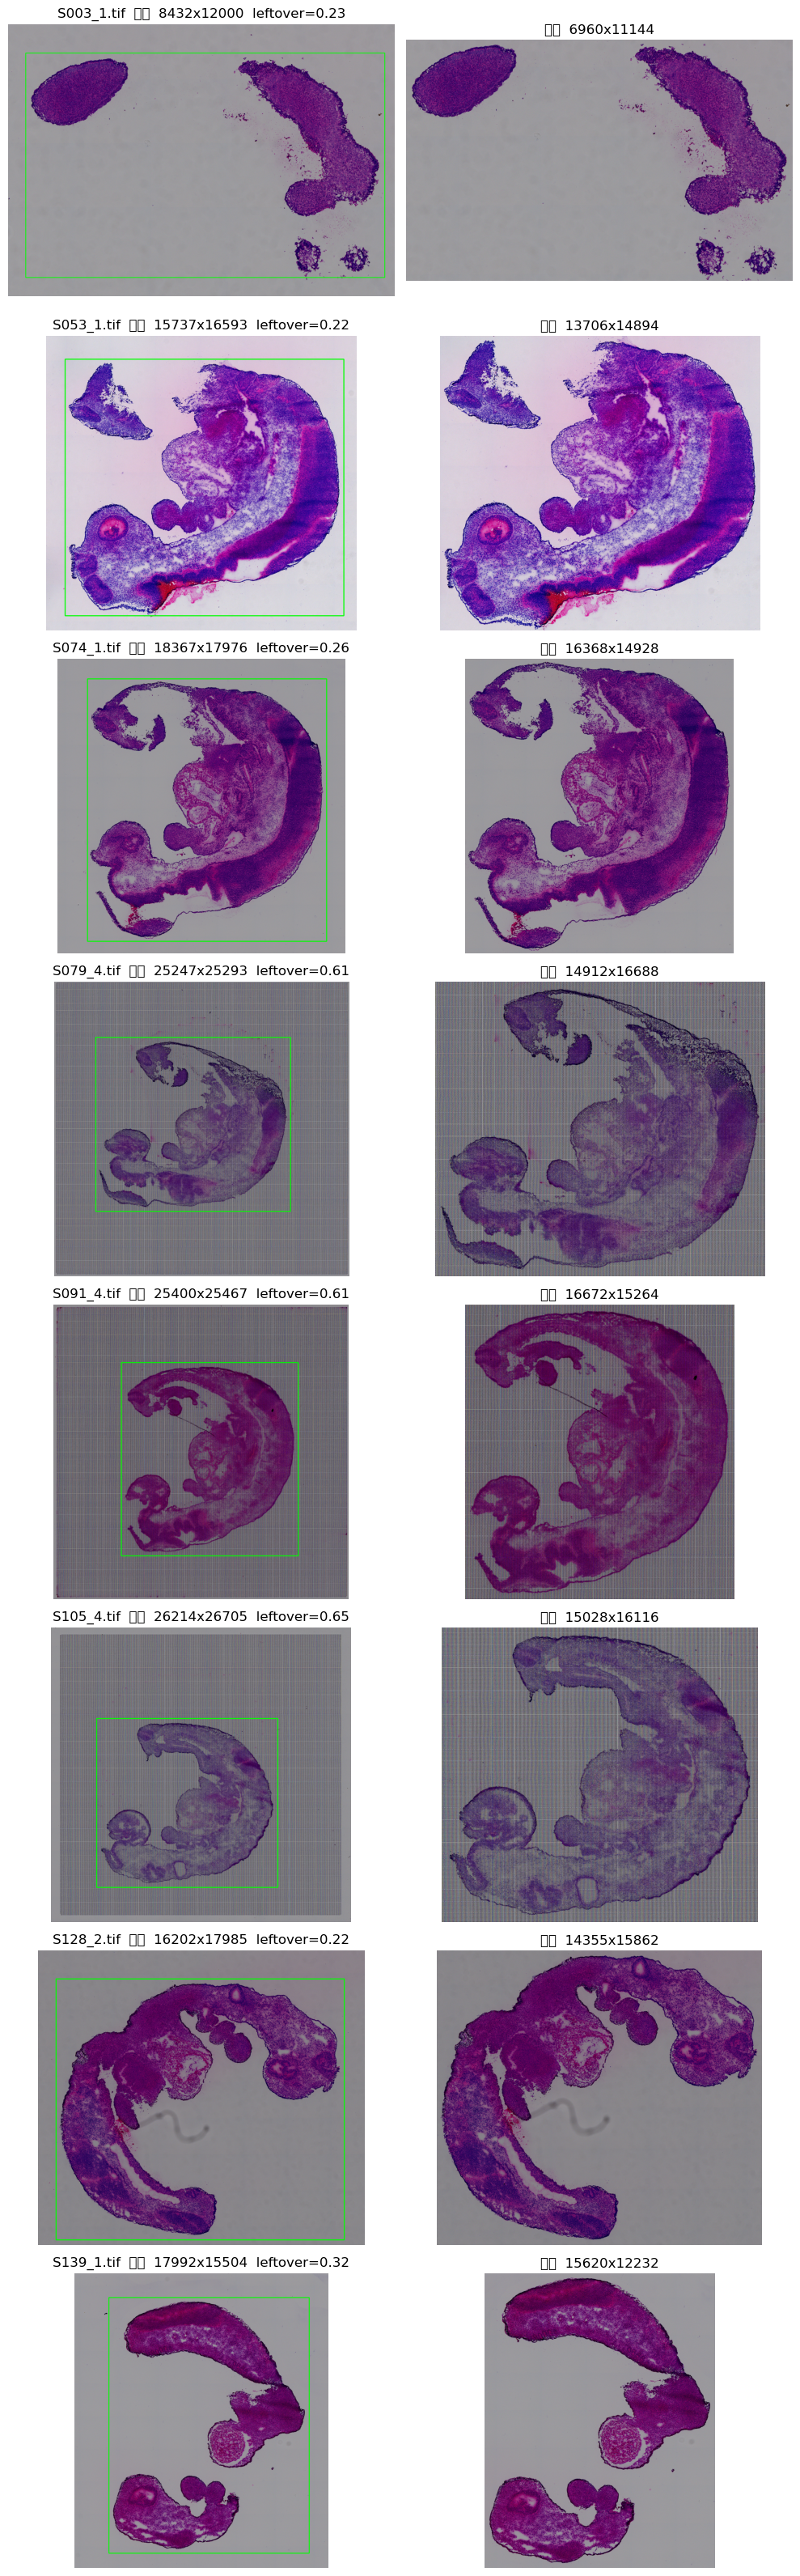

In [ ]:
import os
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt

HE_unscaled_dir = "/mnt/zzf_nas/A_xff/Spaceland-omics/data/interim/PGD_dataset/HE_unscaled"
downsample_dir = os.path.join(HE_unscaled_dir, "downsample_image")

# 组织包围盒外空白占整图面积超过该比例才裁剪；S079_4/S091_4/S105_4 约 0.60
BLANK_AREA_FRAC_THRESH = 0.20
MIN_BBOX_AREA_FRAC = 0.05  # 检测失败保护：包围盒过小则不裁
PAD_FRAC = 0.015
DETECT_MAX_SIDE = 1500
TMP_SUFFIX = ".crop.tmp"


def estimate_tissue_bbox(rgb_small, pad_frac=PAD_FRAC):
    """用四边中位色当背景，前景=与背景色差大的像素，返回含 padding 的 (x0,y0,x1,y1)。"""
    h, w = rgb_small.shape[:2]
    bw = max(4, min(h, w) // 40)
    border = np.concatenate(
        [
            rgb_small[:bw].reshape(-1, 3),
            rgb_small[-bw:].reshape(-1, 3),
            rgb_small[:, :bw].reshape(-1, 3),
            rgb_small[:, -bw:].reshape(-1, 3),
        ],
        axis=0,
    )
    bg = np.median(border.astype(np.float32), axis=0)
    dist = np.linalg.norm(rgb_small.astype(np.float32) - bg, axis=2)
    dist_u8 = cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    dist_u8 = cv2.GaussianBlur(dist_u8, (5, 5), 0)
    _, mask = cv2.threshold(dist_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    k = max(5, int(min(h, w) * 0.006) | 1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((k, k), np.uint8))
    k2 = max(9, int(min(h, w) * 0.012) | 1)
    mask = cv2.morphologyEx(
        mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k2, k2))
    )

    n_cc, cc, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    min_area = max(150, int(0.0008 * h * w))
    keep = [i for i in range(1, n_cc) if stats[i, cv2.CC_STAT_AREA] >= min_area]
    if not keep:
        return None

    ys, xs = np.where(np.isin(cc, keep))
    pad = int(pad_frac * max(h, w))
    x0 = max(0, int(xs.min()) - pad)
    y0 = max(0, int(ys.min()) - pad)
    x1 = min(w, int(xs.max()) + 1 + pad)
    y1 = min(h, int(ys.max()) + 1 + pad)
    return x0, y0, x1, y1


def scale_bbox_to_full(bbox, small_hw, full_hw, step):
    x0, y0, x1, y1 = bbox
    sh, sw = small_hw
    H, W = full_hw
    x0o, y0o = x0 * step, y0 * step
    x1o = W if x1 >= sw else min(W, x1 * step)
    y1o = H if y1 >= sh else min(H, y1 * step)
    return x0o, y0o, x1o, y1o


def to_hwc_rgb(img):
    if img.ndim == 2:
        return np.repeat(img[..., None], 3, axis=2)
    if img.ndim == 3 and img.shape[-1] >= 3:
        return img[..., :3]
    if img.ndim == 3 and img.shape[0] in (3, 4):
        return np.moveaxis(img[:3], 0, -1)
    raise ValueError(f"无法解析图像排布: {img.shape}")


def remove_path(p):
    if p and os.path.exists(p):
        os.remove(p)


def cleanup_crop_tmps(dirs):
    """清理历史残留的 .crop.tmp 中间文件。"""
    removed = []
    for d in dirs:
        if not os.path.isdir(d):
            continue
        for name in os.listdir(d):
            if name.endswith(TMP_SUFFIX):
                p = os.path.join(d, name)
                if os.path.isfile(p):
                    os.remove(p)
                    removed.append(p)
    return removed


removed_tmps = cleanup_crop_tmps([HE_unscaled_dir, downsample_dir])
if removed_tmps:
    print(f"启动前清理残留临时文件 {len(removed_tmps)} 个")

cropped, skipped, failed = [], [], []
preview_items = []

for fname in sorted(os.listdir(HE_unscaled_dir)):
    path = os.path.join(HE_unscaled_dir, fname)
    if not os.path.isfile(path) or not fname.lower().endswith((".tif", ".tiff")):
        continue

    tmp_path = path + TMP_SUFFIX
    ds_tmp_path = None
    try:
        img = tifffile.memmap(path)
        img_rgb = to_hwc_rgb(img)
        H, W = img_rgb.shape[:2]
        step = max(1, max(H, W) // DETECT_MAX_SIDE)
        small = np.ascontiguousarray(img_rgb[::step, ::step, :3])
        bbox_s = estimate_tissue_bbox(small)
        if bbox_s is None:
            skipped.append((fname, "未检测到组织", (H, W)))
            print(f"[跳过] {fname}  未检测到组织  shape={H}x{W}")
            del img
            continue

        x0, y0, x1, y1 = scale_bbox_to_full(bbox_s, small.shape[:2], (H, W), step)
        bbox_area = (x1 - x0) * (y1 - y0)
        leftover = 1.0 - bbox_area / float(H * W)
        if bbox_area < MIN_BBOX_AREA_FRAC * H * W:
            skipped.append((fname, f"包围盒过小 leftover={leftover:.3f}", (H, W)))
            print(f"[跳过] {fname}  包围盒过小  leftover={leftover:.3f}  box={y1-y0}x{x1-x0}")
            del img
            continue
        if leftover < BLANK_AREA_FRAC_THRESH:
            skipped.append((fname, f"空白不足 leftover={leftover:.3f}", (H, W)))
            print(f"[跳过] {fname}  leftover={leftover:.3f} < {BLANK_AREA_FRAC_THRESH}  shape={H}x{W}")
            del img
            continue

        # 预览用：裁前（画框）+ 裁后（低分辨率裁切区域），避免把全分辨率图留在内存
        sx0, sy0, sx1, sy1 = bbox_s
        before_vis = small.copy()
        cv2.rectangle(
            before_vis,
            (sx0, sy0),
            (sx1, sy1),
            (0, 255, 0),
            max(2, before_vis.shape[0] // 400),
        )
        after_vis = np.ascontiguousarray(small[sy0:sy1, sx0:sx1].copy())

        cropped_img = np.ascontiguousarray(img_rgb[y0:y1, x0:x1])
        tifffile.imwrite(tmp_path, cropped_img, photometric="rgb")
        os.replace(tmp_path, path)
        tmp_path = None  # replace 成功后不再存在

        ds_path = os.path.join(downsample_dir, fname)
        if os.path.isfile(ds_path):
            ds = tifffile.imread(ds_path)
            ds_rgb = to_hwc_rgb(ds)
            sy, sx = ds_rgb.shape[0] / H, ds_rgb.shape[1] / W
            dy0, dy1 = int(round(y0 * sy)), int(round(y1 * sy))
            dx0, dx1 = int(round(x0 * sx)), int(round(x1 * sx))
            dy0, dx0 = max(0, dy0), max(0, dx0)
            dy1, dx1 = min(ds_rgb.shape[0], dy1), min(ds_rgb.shape[1], dx1)
            ds_tmp_path = ds_path + TMP_SUFFIX
            tifffile.imwrite(
                ds_tmp_path,
                np.ascontiguousarray(ds_rgb[dy0:dy1, dx0:dx1]),
                photometric="rgb",
                compression="packbits",
            )
            os.replace(ds_tmp_path, ds_path)
            ds_tmp_path = None
            del ds, ds_rgb

        crop_hw = cropped_img.shape[:2]
        preview_items.append((fname, before_vis, after_vis, leftover, (H, W), crop_hw))
        cropped.append((fname, (H, W), crop_hw, leftover))
        print(f"[裁剪] {fname}  {H}x{W} -> {crop_hw[0]}x{crop_hw[1]}  leftover={leftover:.3f}")
        del img, img_rgb, cropped_img, small
    except Exception as e:
        failed.append((fname, str(e)))
        print(f"[失败] {fname}  {e}")
        remove_path(tmp_path)
        remove_path(ds_tmp_path)

# 收尾再扫一遍，避免异常中断留下中间文件
leftover_tmps = cleanup_crop_tmps([HE_unscaled_dir, downsample_dir])
if leftover_tmps:
    print(f"收尾清理临时文件 {len(leftover_tmps)} 个")

print(f"\n完成: 裁剪 {len(cropped)} 个，跳过 {len(skipped)} 个，失败 {len(failed)} 个")
print(f"空白阈值 BLANK_AREA_FRAC_THRESH={BLANK_AREA_FRAC_THRESH}")

if preview_items:
    n = len(preview_items)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, 0)
    for row, (fname, before_vis, after_vis, leftover, full_hw, crop_hw) in zip(axes, preview_items):
        row[0].imshow(before_vis)
        row[0].set_title(f"{fname}  before  {full_hw[0]}x{full_hw[1]}  leftover={leftover:.2f}")
        row[0].axis("off")
        row[1].imshow(after_vis)
        row[1].set_title(f"after  {crop_hw[0]}x{crop_hw[1]}")
        row[1].axis("off")
    plt.tight_layout()
    plt.show()
